**Goal:** take a pile of points with **no labels** and let K-Means find the groups. You will
fit K-Means, read its centroids and per-point distances, see that "similarity" is just
**distance to a centroid**, pick the number of clusters with the elbow and the silhouette
score, and then watch the same algorithm fail on a banana-shaped dataset -- the failure that
sets up L24. Pairs with the concept note [K-Means Clustering & Similarity](l23_concept_kmeans_clustering.qmd).

> **Previously:** L22 -- The Transformer Architecture (Unit V; Exam II covers it)  |  **Next:** L24 -- Hierarchical & Density-Based Clustering

> This page is the read-only view. To run the lab, open the notebook
> (`l23_lab_kmeans_clustering.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

We have **1500 points in 2-D and no answer key** -- no class, no label, nothing but the
coordinates. Our job is the unsupervised one: find the structure that is already in the data.
The points happen to fall in four roughly round blobs, but K-Means is never told that; it has
to discover the groups from distance alone. We keep the true labels off to the side for one
purpose only -- to *score* the clustering at the very end -- and the algorithm never sees them.

The data is **synthetic** (a fixed seed, identical for everyone). Two dimensions keeps every
step plottable.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second
imports, seeds, and builds the data.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# Four roughly round, well-separated blobs in 2-D. We keep y_true ONLY to score the
# clustering at the end -- K-Means never sees it.
X, y_true = make_blobs(n_samples=1500, centers=4, cluster_std=0.70, random_state=0)
print(X.shape[0], "points,", X.shape[1], "features, and no labels for clustering")

1500 points, 2 features, and no labels for clustering


~~~text
1500 points, 2 features, and no labels for clustering
~~~

## Step 1: Cluster It -- No Labels Required

K-Means asks one thing up front: **how many clusters, `k`?** Say four for now (we will learn
to choose `k` in Step 3). `fit_predict` runs the algorithm and hands back a cluster label for
every point:

In [3]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

print("first 10 cluster labels:", y_pred[:10])
print("points per cluster:    ", np.bincount(y_pred))
print("centroids (rounded):")
print(kmeans.cluster_centers_.round(2))

first 10 cluster labels: [0 0 0 2 1 0 3 2 0 0]
points per cluster:     [373 375 375 377]
centroids (rounded):
[[ 0.89  4.29]
 [-1.28  7.8 ]
 [-1.58  2.93]
 [ 2.1   0.9 ]]


~~~text
first 10 cluster labels: [0 0 0 2 1 0 3 2 0 0]
points per cluster:     [373 375 375 377]
centroids (rounded):
[[ 0.89  4.29]
 [-1.28  7.8 ]
 [-1.58  2.93]
 [ 2.1   0.9 ]]
~~~

K-Means split the 1500 points into four nearly equal groups and reported a **centroid** (the
mean point) for each. One thing to internalize now: those labels `0,1,2,3` are **arbitrary
integers**, not classes. There is no sense in which cluster `0` is "the first" group -- run
K-Means again with a different seed and the same blob might be called `2`. The numbers name
groups; they carry no meaning of their own. Plot them to see the partition:

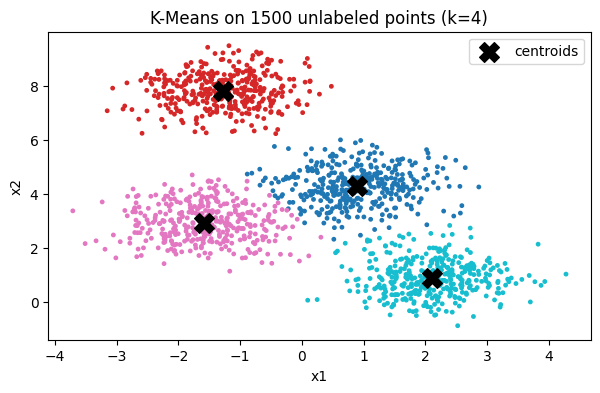

In [4]:
plt.figure(figsize=(7, 4))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=6, cmap="tab10")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker="X", s=200, c="black", label="centroids")
plt.legend(); plt.title("K-Means on 1500 unlabeled points (k=4)")
plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

You should see four well-separated blobs, each drawn in its own color with a black **X** marking
its centroid -- the partition K-Means found from distance alone, with no labels to guide it.

## Step 2: Similarity Is Distance

K-Means has exactly one notion of "similar": **close in Euclidean distance to a centroid**.
Every point is assigned to its nearest centroid, full stop. `transform` makes that explicit --
it returns each point's distance to all four centroids. Try three brand-new points:

In [5]:
X_new = np.array([[0.0, 4.0], [-1.0, 8.0], [2.0, 1.0]])
dist = kmeans.transform(X_new)
print("distance to each of the 4 centroids (rounded):")
print(dist.round(2))
print("nearest-centroid label:", kmeans.predict(X_new))
print("affinity 1/(1+distance):")
print((1 / (1 + dist)).round(2))

distance to each of the 4 centroids (rounded):
[[0.94 4.01 1.91 3.74]
 [4.16 0.35 5.1  7.75]
 [3.47 7.55 4.07 0.14]]
nearest-centroid label: [0 1 3]
affinity 1/(1+distance):
[[0.52 0.2  0.34 0.21]
 [0.19 0.74 0.16 0.11]
 [0.22 0.12 0.2  0.88]]


~~~text
distance to each of the 4 centroids (rounded):
[[0.94 4.01 1.91 3.74]
 [4.16 0.35 5.1  7.75]
 [3.47 7.55 4.07 0.14]]
nearest-centroid label: [0 1 3]
affinity 1/(1+distance):
[[0.52 0.2  0.34 0.21]
 [0.19 0.74 0.16 0.11]
 [0.22 0.12 0.2  0.88]]
~~~

Each new point is assigned to the centroid it is **closest** to (smallest distance in its row).
Distance runs from 0 to infinity, which is awkward to compare, so we often turn it into an
**affinity** with `1/(1+distance)`: 1 when you are sitting on the centroid, fading toward 0 as
you move away. The third point sits almost on top of centroid 3 (distance 0.14, affinity 0.88).

That "assign to the nearest centroid" rule is not a black box -- it is just an `argmin` over the
distance rows. We can reproduce K-Means' own assignments by hand and check they match:

In [6]:
byhand = kmeans.transform(X).argmin(axis=1)
print("assign-to-nearest by hand == sklearn labels_?", np.all(byhand == kmeans.labels_))

assign-to-nearest by hand == sklearn labels_? True


~~~text
assign-to-nearest by hand == sklearn labels_? True
~~~

They agree exactly. That `argmin` over distances is half of the K-Means loop; the other half is
recomputing each centroid as the **mean** of the points assigned to it. Alternate the two until
the centroids stop moving and you have the Lloyd algorithm.

## Step 3: How Many Clusters?

We told K-Means `k=4`, but on real data you do not know `k`. The obvious idea -- pick the `k`
with the lowest **inertia** (the within-cluster sum of squared distances K-Means minimizes) --
does not work. Watch inertia as `k` grows:

In [7]:
inertias = [KMeans(n_clusters=kk, random_state=42).fit(X).inertia_ for kk in range(1, 10)]
for kk, val in zip(range(1, 10), inertias):
    print(f"  k={kk}: inertia {val:8.1f}")

  k=1: inertia  14370.7
  k=2: inertia   6162.9
  k=3: inertia   2831.6
  k=4: inertia   1352.2
  k=5: inertia   1227.4
  k=6: inertia   1115.8
  k=7: inertia    993.2
  k=8: inertia    896.6
  k=9: inertia    789.2


~~~text
  k=1: inertia  14370.7
  k=2: inertia   6162.9
  k=3: inertia   2831.6
  k=4: inertia   1352.2
  k=5: inertia   1227.4
  k=6: inertia   1115.8
  k=7: inertia    993.2
  k=8: inertia    896.6
  k=9: inertia    789.2
~~~

Inertia **only ever falls** as `k` rises -- more centroids always sit closer to the points, and
at `k = n` it hits zero. So you cannot pick `k` by minimizing it. But look at *how* it falls: a
huge drop through `k=4` (14371 -> 1352), then a near-flat crawl. That bend is the **elbow**:
the point where extra clusters stop buying you much. Plot it to see the kink:

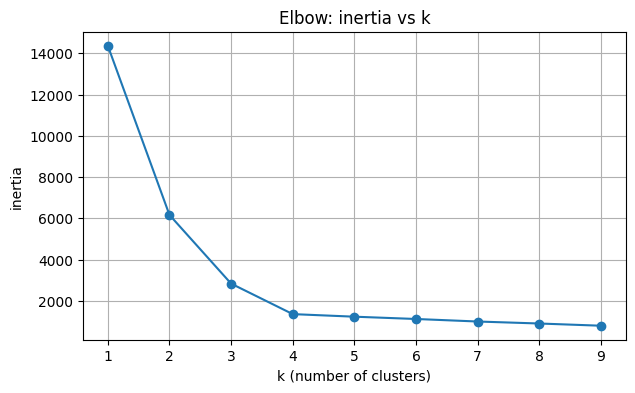

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, 10), inertias, "o-")
plt.xlabel("k (number of clusters)"); plt.ylabel("inertia")
plt.title("Elbow: inertia vs k"); plt.grid(True); plt.show()

The elbow is a judgment call by eye. The **silhouette score** makes it quantitative: for each
point it compares how close it sits to its own cluster versus the nearest other cluster, scored
from -1 (wrong cluster) to +1 (deep inside the right one); the mean over all points is the
silhouette score, and the best `k` is the one that **maximizes** it. Complete the sweep:

In [9]:
# Uncomment and complete the marked line, then run:
# sil = [silhouette_score(X, KMeans(n_clusters=____, random_state=42).fit(X).labels_)  # cluster count = the loop variable
#        for kk in range(2, 10)]
# for kk, s in zip(range(2, 10), sil):
#     print(f"  k={kk}: silhouette {s:.3f}")
# print("best k (max silhouette):", list(range(2, 10))[int(np.argmax(sil))])

<details><summary>Expected Output</summary>

~~~text
  k=2: silhouette 0.538
  k=3: silhouette 0.573
  k=4: silhouette 0.627
  k=5: silhouette 0.536
  k=6: silhouette 0.465
  k=7: silhouette 0.428
  k=8: silhouette 0.308
  k=9: silhouette 0.329
~~~

~~~text
best k (max silhouette): 4
~~~

The silhouette score rises to a clear peak at **k=4 (0.627)**, then declines -- it recovered the
true number of blobs (the far tail wobbles a little, but k=4 is the unambiguous maximum). The
blank is `n_clusters=kk`: each pass clusters with
the current loop value `kk` and scores the result. Silhouette is costlier than inertia (it
measures every point against every cluster) but, unlike inertia, it actually points to a `k`.
</details>

## Step 4: Where K-Means Breaks

K-Means recovered four round blobs almost perfectly. But its one tool -- distance to a
centroid -- bakes in an assumption: clusters are **round, similar-size blobs**. When the real
groups are not shaped like that, K-Means fails. The classic example is two interleaved
crescents (`make_moons`). Run the same algorithm and score it against the true crescents with
the **Adjusted Rand Index** (ARI: 1.0 = perfect match to the true grouping, 0 = random):

In [10]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
km_moons = KMeans(n_clusters=2, random_state=42).fit(X_moons)

print("MOONS  silhouette:           ", round(silhouette_score(X_moons, km_moons.labels_), 3))
print("MOONS  ARI vs true crescents:", round(adjusted_rand_score(y_moons, km_moons.labels_), 3))
print("BLOBS  ARI vs truth:         ", round(adjusted_rand_score(y_true, y_pred), 3))

MOONS  silhouette:            0.489
MOONS  ARI vs true crescents: 0.239
BLOBS  ARI vs truth:          0.962


~~~text
MOONS  silhouette:            0.489
MOONS  ARI vs true crescents: 0.239
BLOBS  ARI vs truth:          0.962
~~~

On the blobs, K-Means matched the truth almost perfectly (**ARI 0.962**). On the moons it
**collapses to ARI 0.239** -- barely better than guessing. Plot it and you see why: K-Means can
only draw straight Voronoi boundaries, so it slices each crescent in half instead of wrapping
it.

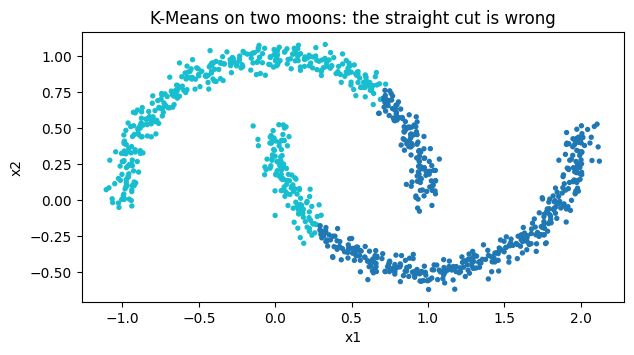

In [11]:
plt.figure(figsize=(7, 3.5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, s=8, cmap="tab10")
plt.title("K-Means on two moons: the straight cut is wrong")
plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

A crescent is a continuous, *connected* region, not a ball around a center -- exactly the kind
of structure K-Means cannot see. That is the opening for **L24**, where DBSCAN clusters by
density (connected dense regions) and hierarchical clustering merges by linkage, both of which
wrap a crescent that K-Means cuts in two.

## Your Turn

### Exercise 1 -- Always scale first

K-Means measures distance, so a feature on a larger numeric scale dominates the result. Here
are four groups arranged in a 2x2 grid, but feature 1 is on a scale about **1000x** larger than
feature 0. Cluster the data **as-is**, then again after `StandardScaler`, and score each against
the true groups with ARI.

In [12]:
rng = np.random.RandomState(42)
n = 250
rows, labels, lab = [], [], 0
for cs in (0.0, 1.0):              # feature 0: small scale
    for cb in (0.0, 1000.0):       # feature 1: large scale (about 1000x)
        rows.append(np.column_stack([rng.normal(cs, 0.10, n), rng.normal(cb, 100.0, n)]))
        labels.append(np.full(n, lab)); lab += 1
Xg = np.vstack(rows); yg = np.concatenate(labels)
print("Xg shape:", Xg.shape)

Xg shape: (1000, 2)


~~~text
Xg shape: (1000, 2)
~~~

**Hint:** fit `KMeans(n_clusters=4, random_state=42)` on `Xg`, then on `StandardScaler().fit_transform(Xg)`; print `adjusted_rand_score(yg, labels_)` for each.

In [13]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
ARI unscaled: 0.334
ARI scaled:   1.0
~~~

Unscaled, the big-scale feature 1 swamps the distance: K-Means can only "see" that axis, finds
the two-way split along it, and butchers the rest -- **ARI 0.334**. After `StandardScaler` gives
both features equal spread, all four groups separate cleanly -- **ARI 1.0**. Scaling is not
optional for K-Means; it is part of the recipe (the same standardization you used in L08/L10).
</details>

### Exercise 2 -- Let the silhouette pick k

Here is a fresh dataset where you do **not** know the number of clusters. Sweep `k` from 2 to 7,
score each with the silhouette, and report the `k` it favors.

In [14]:
Xe, ye = make_blobs(n_samples=900, centers=3, cluster_std=0.50, random_state=7)
print("Xe shape:", Xe.shape, "-- how many clusters? you decide from the silhouette")

Xe shape: (900, 2) -- how many clusters? you decide from the silhouette


~~~text
Xe shape: (900, 2) -- how many clusters? you decide from the silhouette
~~~

**Hint:** reuse the Step 3 pattern -- a list comprehension over `range(2, 8)` calling `silhouette_score` on each `KMeans(...).labels_`, then `np.argmax`.

In [15]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
  k=2: silhouette 0.784
  k=3: silhouette 0.896
  k=4: silhouette 0.699
  k=5: silhouette 0.497
  k=6: silhouette 0.312
  k=7: silhouette 0.328
best k: 3
~~~

The silhouette peaks sharply at **k=3 (0.896)**, well above k=2 (0.784) -- there really were
three centers. This is the everyday clustering workflow: you rarely know `k`, so you sweep it
and let a score like the silhouette choose.
</details>

## Summary

- K-Means clusters **unlabeled** points by distance to `k` **centroids**; the labels it returns
  are arbitrary integers, not classes.
- "Similarity" is **Euclidean distance to a centroid**: `transform` gives the distances,
  `1/(1+d)` turns them into affinities, and assign-to-nearest (`argmin`) reproduces `labels_`.
- You cannot pick `k` by minimizing **inertia** (it only falls); use the **elbow** (here at k=4)
  or, better, the `k` that maximizes the **silhouette score** (0.627 at k=4).
- K-Means assumes round, similar-size blobs: it nailed the blobs (ARI 0.962) but **collapsed on
  the two moons (ARI 0.239)** -- straight cuts cannot wrap a crescent.
- Always **scale features first** (Ex1: ARI 0.334 -> 1.0), and let a score pick `k` (Ex2: the
  silhouette found k=3).
- Next (L24): hierarchical and density-based clustering -- DBSCAN and agglomerative -- which
  handle the crescent shapes K-Means cannot.